In [1]:
#Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from  density_app.functions.fitting_and_error import get_parabolic_fit, get_extended_xs, extract_model_coeffs, get_density_error_from_parabolic_fit, get_parabola_extrema
from density_app.functions.formatting import formatter

In [2]:
#Experimental constants go here

temperature = 80
d1_resonance = 7.94768E-5
d2_resonance = 7.80034E-5
optical_length = 3.7
oscillator = 0.667
#k = 7/6
#T_d = 34e-13
#line_w = 3e9

#File(s) to use
file1 = '09132024_density_with_no_verdet.csv'
file2 = '09132024_density_with_verdet.csv'
#file3 = '09132024_density_with_verdet_asymmetry.csv'
#file4 = '09132024_density_with_verdet_asymmetry_alt.csv'

In [3]:
#Functions for data processing go here for now

#Get data from specified file
def get_plot_data(file, T):
    data_unsorted = pd.read_csv(file)
    data = data_unsorted.sort_values('Probe Beam')
    killian_density = data.loc[data['Temperature']== T, 'Killian Value']
    paramag_density = data.loc[data['Temperature']== T, 'Density (with Paramagentic term)'].to_numpy()
    paramag_density_error = data.loc[data['Temperature']== T, 'Density Error (with Paramagentic term)'].to_numpy()
    probe_beam = data.loc[data['Temperature']== T, 'Probe Beam'].to_numpy()
    return killian_density, paramag_density, paramag_density_error, probe_beam



def datapoints_nice(xs, densities):
    df = pd.DataFrame({'Detuning': xs, 
                       'Density': densities })
    return df



In [4]:
#extract data from files
killian_density, paramag_density, paramag_density_error, probe_beam = get_plot_data(file1, temperature) #uncorrected for Verdet
killian_density_V, paramag_density_V, paramag_density_error_V, probe_beam_V = get_plot_data(file2, temperature)

#adjust x values to center data around resonance
x_fit = probe_beam-d2_resonance

#fit data and get coefficients and covariance matrix
my_fit, cv = get_parabolic_fit(x_fit, paramag_density, paramag_density_error)

#minimize fix, get x and y coords for minimum value
min_density_x, min_density = get_parabola_extrema(my_fit)

#get the density error from the fit
rb_den_final_error = get_density_error_from_parabolic_fit(cv)

#print fit and covariance matrix to test that you're data is doing data things
#print(my_fit)
#print(cv)

TypeError: get_extended_xs() missing 1 required positional argument: 'extension_percent'

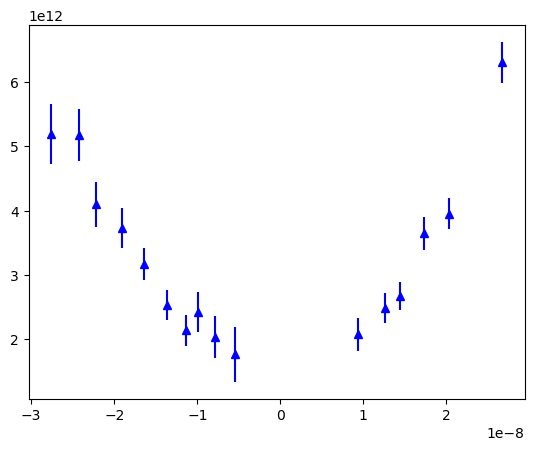

In [ ]:
#PLOTS STUFF, MAKE PRETTY GRAPHS

#format the important values nicely so they don't hurt to look at
min_density_fmt = formatter(min_density, 2)
rb_den_final_error_fmt = formatter(rb_den_final_error, 2)
den_text = "Density: "+min_density_fmt+r" $ \pm $ "+rb_den_final_error_fmt

#figure setup
fig = plt.figure()
ax = fig.add_subplot()
fig.subplots_adjust(top=0.89)


#plot the data sets
ax.errorbar(x=probe_beam-d2_resonance, y=paramag_density, yerr=paramag_density_error, color='blue', marker='^', linestyle='none', label = 'Uncorrected [Rb] measurements')
#plot the parabolic fit
polyline = get_extended_xs(x_fit, 100, .1)
ax.plot(polyline, my_fit(polyline), color='blue', label = 'Parabolic fit') 
#plot experimental data points
ax.errorbar(x=probe_beam-d2_resonance, y=paramag_density_V, yerr=paramag_density_error_V, color='orange', marker='o', linestyle='none', label = '[Rb] with verdet adjustment')
#plot tangent line at minimum
ax.axhline(y=min_density, color = "orange", label = "True [Rb]")


#set up labels, titles, grid
fig.suptitle("Probe Beam Detuning vs. [Rb] at %dC"%(temperature))
ax.set_title(den_text)
ax.legend()
ax.set_xlabel("Probe Beam Detuning (cm)")
ax.set_ylabel("[Rb]")
ax.grid(visible=True, which='both', axis='both')

#Print out Density info, for easy copypasting if necessary
print("Alkali Metal Density: ", min_density_fmt)
print("Density Error: ", rb_den_final_error_fmt)

#display the plot
plt.show()
